In [1]:
import pandas as pd
import numpy as np

# Import winequality-red.csv with semicolon separator
wine_data = pd.read_csv('winequality-red.csv', sep=';')

# Display basic information about the dataset
print("Dataset shape:", wine_data.shape)
print("\nFirst few rows:")
print(wine_data.head())

print("\nDataset info:")
print(wine_data.info())

print("\nColumn names:")
print(wine_data.columns.tolist())

# Separate features and target
X = wine_data.drop('quality', axis=1)  # 'quality' is the target column
y = wine_data['quality']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target values: {sorted(y.unique())}")

Dataset shape: (1599, 12)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  

In [ ]:
import numpy as np
from time import time
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from scipy.stats import randint, loguniform
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=5)

pipeline = Pipeline(
    steps=[("preprocess", StandardScaler()),
           ("regress", MLPRegressor(max_iter=5000))]
)

model_params = {'regress__alpha': loguniform(1e-4, 10),
                'regress__solver': ['sgd','adam'],
                'regress__hidden_layer_sizes': 
                    [(i, j, k) for i in range(10, 51) for j in range(10, i+1) for k in range(10, j+1)],
                'regress__activation': ['identity','logistic','tanh','relu']}
n_iter = 30
random_search = RandomizedSearchCV(pipeline,
                                   param_distributions=model_params, 
                                   n_iter=n_iter, verbose=3)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), n_iter))

# Print best parameters after tuning
print(random_search.best_params_)
  
# Print how our model looks after hyper-parameter tuning
print(random_search.best_estimator_)

In [ ]:
X_all = pd.concat([X_train, X_test])
y_pred = random_search.predict(X_all)
plt.plot(np.arange(0,len(y_train)), y_train,'b',label='Training Data')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test, 'm', label='Test Data')
plt.plot(np.arange(0,len(y_train)+len(y_test)),y_pred,color='r',label='Random Search Prediction')
plt.legend()
plt.grid()
plt.show()
train_mse = mean_squared_error(y_train, y_pred[:len(y_train)])
test_mse = mean_squared_error(y_test, y_pred[len(y_train):])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")


# loss_values = random_search.best_estimator_[1].loss_curve_
# plt.plot(loss_values,'r')
# plt.title('Training Loss for Best MLP')
# plt.grid()
# plt.show()
# train_mse = mean_squared_error(y_train, y_pred[:len(y_train)])
# test_mse = mean_squared_error(y_test, y_pred[len(y_train):])
# print(f"Training MSE: {train_mse}")
# print(f"Testing MSE: {test_mse}")

train_r2  = r2_score(y_train, y_pred[:len(y_train)])
test_r2   = r2_score(y_test, y_pred[len(y_train):])
train_mad = mean_absolute_error(y_train, y_pred[:len(y_train)])
test_mad  = mean_absolute_error(y_test, y_pred[len(y_train):])

print(f"Training R2: {train_r2}, Training MAD: {train_mad}")
print(f"Testing R2: {test_r2}, Testing MAD: {test_mad}")

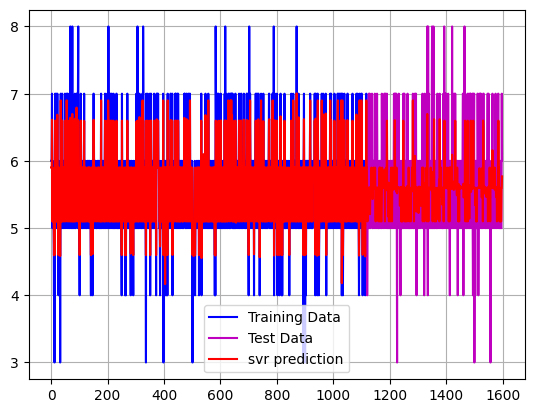

Training MSE: 0.07058136399733192
Testing MSE: 0.5266747493823208
Training R2: 0.8905485113771302, Training MAD: 0.168234591264848
Testing R2: 0.2106816127902773, Testing MAD: 0.5656743315480602


In [4]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

svr = make_pipeline(StandardScaler(),
                    SVR(kernel='rbf',gamma=5)).fit(X_train,y_train)

X_all = pd.concat([X_train, X_test])
y_svr = svr.predict(X_all)
plt.plot(np.arange(0,len(y_train)), y_train,'b',label='Training Data')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test, 'm', label='Test Data')
plt.plot(np.arange(0,len(y_train)+len(y_test)),y_svr,color='r',label='svr prediction')
plt.legend()
plt.grid()
plt.show()
train_mse = mean_squared_error(y_train, y_svr[:len(y_train)])
test_mse = mean_squared_error(y_test, y_svr[len(y_train):])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")

train_r2  = r2_score(y_train, y_svr[:len(y_train)])
test_r2   = r2_score(y_test, y_svr[len(y_train):])
train_mad = mean_absolute_error(y_train, y_svr[:len(y_train)])
test_mad  = mean_absolute_error(y_test, y_svr[len(y_train):])

print(f"Training R2: {train_r2}, Training MAD: {train_mad}")
print(f"Testing R2: {test_r2}, Testing MAD: {test_mad}")


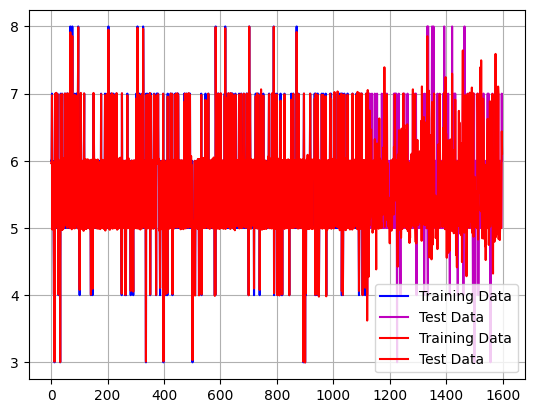

Training MSE: 0.0008512143976986408
Testing MSE: 0.39785537123680115
Training R2: 0.9986799955368042, Training MAD: 0.01910298317670822
Testing R2: 0.4037410020828247, Testing MAD: 0.4296029508113861


In [5]:
import seaborn as sns
import xgboost as xgb
import pandas as pd
import numpy as np
import math
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
# print classification report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
warnings.filterwarnings("ignore")   

# Create regression matrices
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# Define hyperparameters
params = {"objective": "reg:squarederror"}
n = 100

model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n
)

y_pred_train = model.predict(dtrain_reg)
y_pred_test = model.predict(dtest_reg)
X_all = pd.concat([X_train, X_test])
y_pred = model.predict(xgb.DMatrix(X_all, enable_categorical=True))
plt.plot(np.arange(0,len(y_train)), y_train,'b',label='Training Data')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test, 'm', label='Test Data')
plt.plot(np.arange(0,len(y_train)), y_pred_train,'r',label='Training Data')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred_test, 'r', label='Test Data')
plt.legend()
plt.grid()
plt.show()
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")

train_r2  = r2_score(y_train, y_pred_train)
test_r2   = r2_score(y_test, y_pred_test)
train_mad = mean_absolute_error(y_train, y_pred_train)
test_mad  = mean_absolute_error(y_test, y_pred_test)

print(f"Training R2: {train_r2}, Training MAD: {train_mad}")
print(f"Testing R2: {test_r2}, Testing MAD: {test_mad}")

Best hyperparameters: {'max_depth': 13, 'n_estimators': 342}


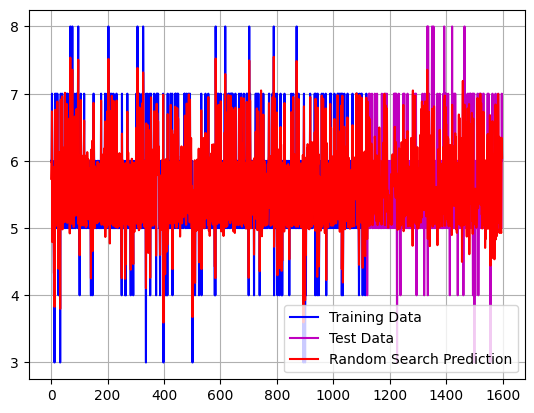

Training MSE: 0.056639509115671734
Testing MSE: 0.3523170673543471
Training R2: 0.9121683368457825, Training MAD: 0.17705379932739954
Testing R2: 0.47198847160086144, Testing MAD: 0.4280244843344698


In [6]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

rf = RandomForestRegressor()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf, 
                                 param_distributions = param_dist, 
                                 n_iter=5, 
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

X_all = pd.concat([X_train, X_test])
y_pred = best_rf.predict(X_all)
plt.plot(np.arange(0,len(y_train)), y_train,'b',label='Training Data')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test, 'm', label='Test Data')
plt.plot(np.arange(0,len(y_train)+len(y_test)),y_pred,color='r',label='Random Search Prediction')
plt.legend()
plt.grid()
plt.show()
train_mse = mean_squared_error(y_train, y_pred[:len(y_train)])
test_mse = mean_squared_error(y_test, y_pred[len(y_train):])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")

train_r2  = r2_score(y_train, y_pred[:len(y_train)])
test_r2   = r2_score(y_test, y_pred[len(y_train):])
train_mad = mean_absolute_error(y_train, y_pred[:len(y_train)])
test_mad  = mean_absolute_error(y_test, y_pred[len(y_train):])

print(f"Training R2: {train_r2}, Training MAD: {train_mad}")
print(f"Testing R2: {test_r2}, Testing MAD: {test_mad}")

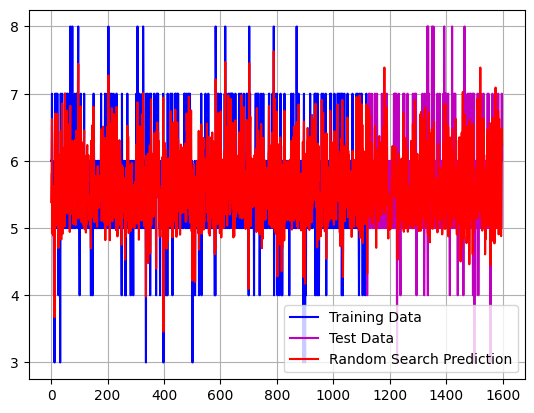

Training MSE: 0.22075286396951185
Testing MSE: 0.39981111845674844
Training R2: 0.6576755079409022, Training MAD: 0.36737419499698415
Testing R2: 0.40080995419107657, Testing MAD: 0.47718209200230743


In [7]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

X_all = pd.concat([X_train, X_test])
y_pred = gbr.predict(X_all)
plt.plot(np.arange(0,len(y_train)), y_train,'b',label='Training Data')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test, 'm', label='Test Data')
plt.plot(np.arange(0,len(y_train)+len(y_test)),y_pred,color='r',label='Random Search Prediction')
plt.legend()
plt.grid()
plt.show()
train_mse = mean_squared_error(y_train, y_pred[:len(y_train)])
test_mse = mean_squared_error(y_test, y_pred[len(y_train):])
print(f"Training MSE: {train_mse}")
print(f"Testing MSE: {test_mse}")

train_r2  = r2_score(y_train, y_pred[:len(y_train)])
test_r2   = r2_score(y_test, y_pred[len(y_train):])
train_mad = mean_absolute_error(y_train, y_pred[:len(y_train)])
test_mad  = mean_absolute_error(y_test, y_pred[len(y_train):])

print(f"Training R2: {train_r2}, Training MAD: {train_mad}")
print(f"Testing R2: {test_r2}, Testing MAD: {test_mad}")